<a href="https://colab.research.google.com/github/maruson08/new-folder-3/blob/main/%EC%A7%80%EA%B5%AC_%EA%B6%A4%EB%8F%84_%EC%98%88%EC%B8%A1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install skyfield

In [ ]:
from skyfield.api import load
ts = load.timescale()
planets = load('de440.bsp')  # DE440 ephemeris 파일 자동 다운로드
earth = planets['earth']
mars = planets['MARS BARYCENTER']

In [ ]:
import numpy as np
# 날짜 범위 설정 (예: 최근 2년간 일 단위)
t = ts.utc(2023, 1, range(1, 730))
# 지구와 화성 위치 계산
astrometric = earth.at(t).observe(mars)
ra, dec, distance = astrometric.radec()
# 겉보기 방위각 계산 (RA 활용하거나 xy 투영)
angles = ra.radians  # 단순 사용 가능
# unwrap 적용하여 순행/역행 패턴 포착
angle = np.unwrap(angles)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
lookback = 30
X, y = [], []
for i in range(len(angle) - lookback):
    X.append(angle[i:i+lookback])
    y.append(angle[i+lookback])
X = np.array(X); y = np.array(y)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1,1))
X_scaled = X_scaled.reshape((X_scaled.shape[0], lookback, 1))


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(lookback, 1)),
    Dense(1)
])
model.compile(loss='mse', optimizer='adam')
model.fit(X_scaled, y_scaled, epochs=50, batch_size=16)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0997
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.9741e-04
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.5969e-05
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.9731e-05
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.6473e-05
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.4238e-05
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.7110e-05
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.5029e-05
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.6638e-05
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.4081e-05
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.6683e-05
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2796e-05
Epoch 13/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2012e-05
Epoch 14/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3128e-05
Epoch 15/50
44/44 ━━━━━━━━━━━━

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

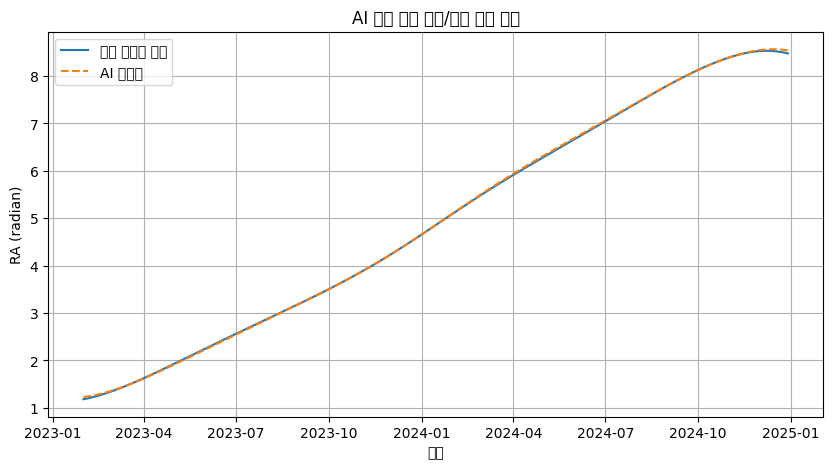

In [ ]:
y_pred = model.predict(X_scaled)
y_pred_inv = scaler.inverse_transform(y_pred)
true = angle[lookback:]

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(t.utc_datetime()[lookback:], true, label='실제 겉보기 위치')
plt.plot(t.utc_datetime()[lookback:], y_pred_inv.flatten(), '--', label='AI 예측값')
plt.title("AI 기반 화성 순행/역행 운동 예측")
plt.xlabel("날짜")
plt.ylabel("RA (radian)")
plt.legend(); plt.grid(True)
plt.show()


In [ ]:
pip install skyfield tensorflow scikit-learn matplotlib streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.8 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


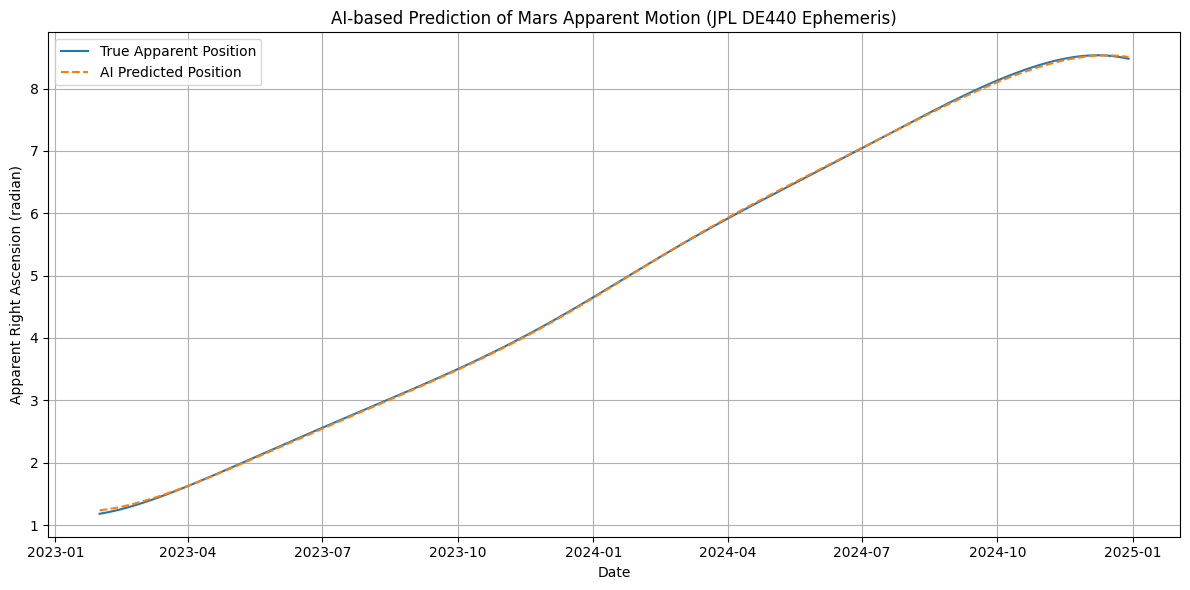

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skyfield.api import load
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Load ephemeris data
ts = load.timescale()
planets = load('de440.bsp')
earth = planets['earth']
mars = planets['MARS BARYCENTER']

# 2. Generate date range (2 years)
t = ts.utc(2023, 1, range(1, 730))

# 3. Compute relative position: Earth observing Mars
astrometric = earth.at(t).observe(mars)
ra, dec, distance = astrometric.radec()
angles = ra.radians
angle = np.unwrap(angles)

# 4. Prepare dataset for LSTM
lookback = 30
X, y = [], []
for i in range(len(angle) - lookback):
    X.append(angle[i:i+lookback])
    y.append(angle[i+lookback])
X = np.array(X)
y = np.array(y)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1,1))
X_scaled = X_scaled.reshape((X_scaled.shape[0], lookback, 1))

# 5. Define and train LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(lookback, 1)))
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
model.fit(X_scaled, y_scaled, epochs=30, batch_size=16, verbose=0)

# 6. Predict and inverse scale
y_pred_scaled = model.predict(X_scaled)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = angle[lookback:]

# 7. Plot in English
dates = t.utc_datetime()[lookback:]
plt.figure(figsize=(12, 6))
plt.plot(dates, y_true, label='True Apparent Position')
plt.plot(dates, y_pred.flatten(), label='AI Predicted Position', linestyle='--')
plt.title("AI-based Prediction of Mars Apparent Motion (JPL DE440 Ephemeris)")
plt.xlabel("Date")
plt.ylabel("Apparent Right Ascension (radian)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


2025-07-14 04:28:47.509 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 04:28:47.891 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-07-14 04:28:47.891 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 04:28:47.894 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 04:28:47.895 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 04:28:47.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 04:28:47.898 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 04:28:47.899 Thread 'MainThread': mi

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


2025-07-14 04:29:07.826 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 04:29:08.290 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 04:29:08.291 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 04:29:08.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

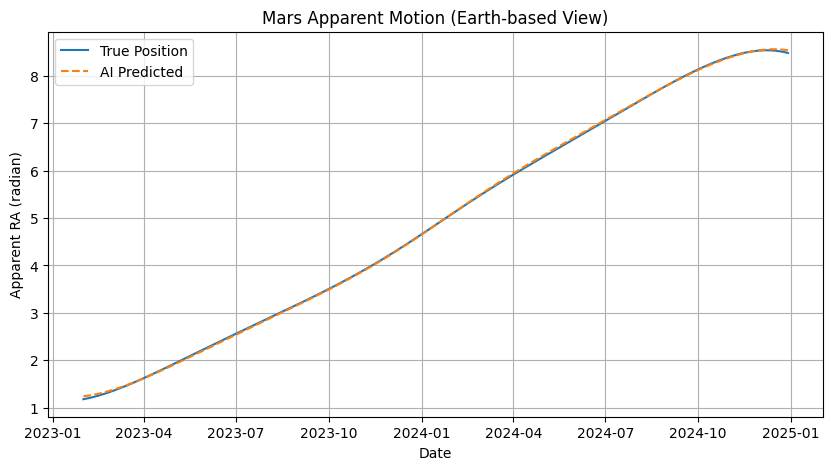

In [ ]:
import streamlit as st
import numpy as np
import matplotlib.pyplot as plt
from skyfield.api import load
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

st.title("AI-based Prediction of Mars Apparent Motion")
st.markdown("This app uses **NASA JPL DE440 ephemeris data** with **LSTM** to predict Mars' retrograde and prograde motion.")

# Settings
year_range = st.slider("Select date range (days)", 365, 1095, 730)

# Load ephemeris
ts = load.timescale()
planets = load('de440.bsp')
earth = planets['earth']
mars = planets['MARS BARYCENTER']
t = ts.utc(2023, 1, range(1, year_range))

# Calculate apparent angle
astrometric = earth.at(t).observe(mars)
ra, dec, distance = astrometric.radec()
angle = np.unwrap(ra.radians)

# LSTM preprocessing
lookback = 30
X, y = [], []
for i in range(len(angle) - lookback):
    X.append(angle[i:i+lookback])
    y.append(angle[i+lookback])
X, y = np.array(X), np.array(y)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1, 1))
X_scaled = X_scaled.reshape((X_scaled.shape[0], lookback, 1))

# LSTM model
model = Sequential([
    LSTM(64, input_shape=(lookback, 1)),
    Dense(1)
])
model.compile(loss='mse', optimizer='adam')
model.fit(X_scaled, y_scaled, epochs=30, batch_size=16, verbose=0)

# Predict
y_pred = model.predict(X_scaled)
y_pred_inv = scaler.inverse_transform(y_pred)
dates = t.utc_datetime()[lookback:]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dates, angle[lookback:], label="True Position")
ax.plot(dates, y_pred_inv.flatten(), '--', label="AI Predicted")
ax.set_title("Mars Apparent Motion (Earth-based View)")
ax.set_xlabel("Date")
ax.set_ylabel("Apparent RA (radian)")
ax.legend()
ax.grid(True)
st.pyplot(fig)


In [ ]:
!pip install astropy

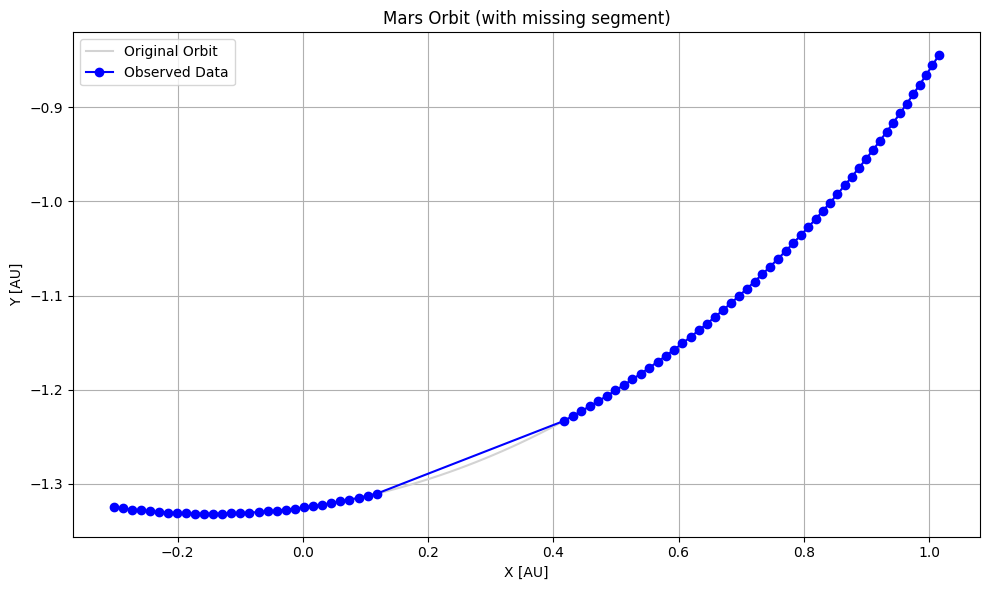

In [ ]:
from astropy.coordinates import get_body_barycentric_posvel
from astropy.time import Time
import matplotlib.pyplot as plt
import numpy as np

# 날짜 설정: 2024년 1월 1일부터 100일간
dates = Time(['2024-01-01']) + np.arange(0, 100)

# 행성 선택: 예시로 'mars'x`, date)[0] for date in dates]
x = [p.x.value for p in positions]
y = [p.y.value for p in positions]

# 결측 구간 시뮬레이션 (30~50일 제거)
mask = np.ones(len(x), dtype=bool)
mask[30:50] = False

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Original Orbit', color='lightgray')
plt.plot(np.array(x)[mask], np.array(y)[mask], 'o-', label='Observed Data', color='blue')
plt.title('Mars Orbit (with missing segment)')
plt.xlabel('X [AU]')
plt.ylabel('Y [AU]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


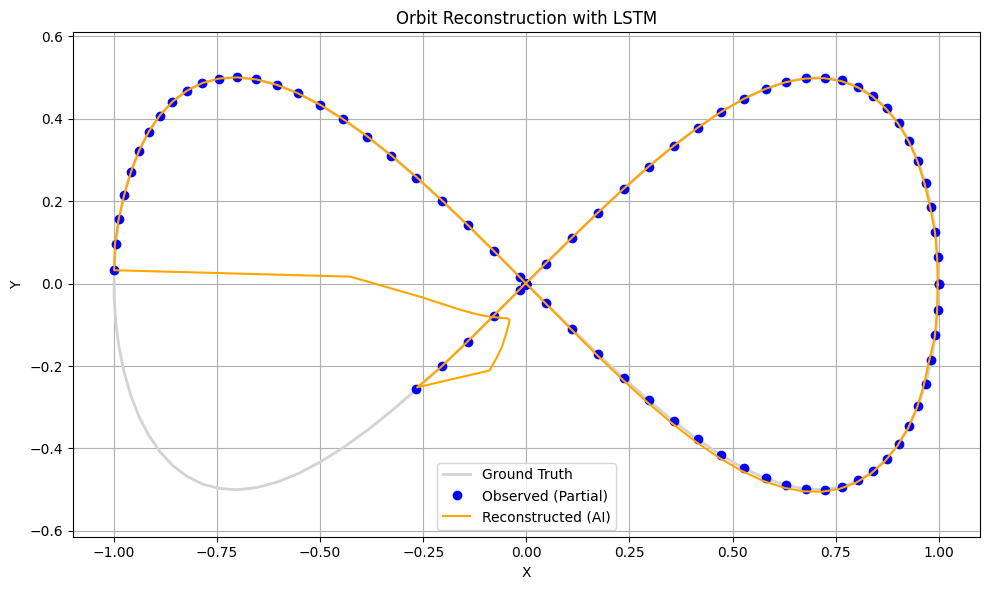

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. 궤도 데이터 생성 (예시: 타원형 곡선)
T = 100
t = np.linspace(0, 2 * np.pi, T)
x = np.cos(t)
y = np.sin(2 * t) / 2
coords = np.stack([x, y], axis=1)

# 2. 결측 구간 마스킹 (30~49)
mask = np.ones(T, dtype=bool)
mask[30:50] = False
observed = coords.copy()
observed[~mask] = 0.0  # 마스킹된 구간은 0으로 설정

# 3. PyTorch 텐서 구성
input_tensor = torch.tensor(observed, dtype=torch.float32).unsqueeze(0)  # (1, T, 2)
mask_tensor = torch.tensor(mask.astype(np.float32)).unsqueeze(0).unsqueeze(2)  # (1, T, 1)

# 4. 모델 정의: 양방향 LSTM → Linear
class OrbitLSTM(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.linear = nn.Linear(hidden_dim * 2, input_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out)

model = OrbitLSTM()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# 5. 학습
for epoch in range(1000):
    model.train()
    output = model(input_tensor)
    loss = criterion(output * mask_tensor, input_tensor * mask_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 6. 결과 예측 및 시각화
model.eval()
with torch.no_grad():
    predicted = model(input_tensor).squeeze().numpy()

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Ground Truth', color='lightgray', linewidth=2)
plt.plot(observed[:, 0], observed[:, 1], 'o', label='Observed (Partial)', color='blue')
plt.plot(predicted[:, 0], predicted[:, 1], '-', label='Reconstructed (AI)', color='orange')
plt.title('Orbit Reconstruction with LSTM')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()
